# Pixel2Mesh — DINOv2 + FPN Encoder

Replaces the ResNet18 backbone with **DINOv2-S** (ViT-S/14) + a lightweight **FPN neck** to recover the multi-scale pyramid that `sample_features` expects.

| Component | Old (notebook 5) | New (this notebook) |
|---|---|---|
| Backbone | ResNet18 | DINOv2 ViT-S/14 |
| Feature pyramid | 4 conv stages | FPN over ViT intermediate layers |
| Feature dims | [64,128,256,512] | [256,256,256,256] |
| Global context | ✗ | ✓ (attention) |
| Self-supervised pre-training | ✗ | ✓ |

Everything downstream (GCN, losses, dataset, training loop) is identical to notebook 5.

## Setup

In [18]:
import torch
torch.backends.quantized.engine = "qnnpack"

import numpy as np

# if torch.backends.mps.is_available():
#     DEVICE = torch.device("mps")
# elif torch.cuda.is_available():
#     DEVICE = torch.device("cuda")
# else:
#     DEVICE = torch.device("cpu")
DEVICE = torch.device("cpu")

torch.manual_seed(42)
np.random.seed(42)
print("Device:", DEVICE)

Device: cpu


## Mesh utilities

Identical to notebook 5 — unit cube template, Loop subdivision, adjacency/Laplacian builders.

In [2]:
def get_unit_cube():
    v = torch.tensor([
        [-0.5, -0.5, -0.5], [ 0.5, -0.5, -0.5],
        [ 0.5,  0.5, -0.5], [-0.5,  0.5, -0.5],
        [-0.5, -0.5,  0.5], [ 0.5, -0.5,  0.5],
        [ 0.5,  0.5,  0.5], [-0.5,  0.5,  0.5],
    ], dtype=torch.float32)
    f = torch.tensor([
        [0,1,2],[0,2,3],
        [4,6,5],[4,7,6],
        [0,4,5],[0,5,1],
        [2,6,7],[2,7,3],
        [0,7,4],[0,3,7],
        [1,5,6],[1,6,2],
    ], dtype=torch.long)
    return v, f


def loop_subdivide(vertices, faces):
    V = vertices.shape[0]
    device = vertices.device
    edges_dict, mids = {}, []

    def midpoint(a, b):
        key = (min(a, b), max(a, b))
        if key not in edges_dict:
            edges_dict[key] = len(mids) + V
            mids.append((vertices[a] + vertices[b]) / 2.0)
        return edges_dict[key]

    new_faces = []
    for tri in faces.numpy():
        v0, v1, v2 = int(tri[0]), int(tri[1]), int(tri[2])
        m01, m12, m20 = midpoint(v0,v1), midpoint(v1,v2), midpoint(v2,v0)
        new_faces += [[v0,m01,m20],[v1,m12,m01],[v2,m20,m12],[m01,m12,m20]]

    new_v = torch.cat([vertices, torch.stack(mids).to(device)], 0) if mids else vertices
    new_f = torch.tensor(new_faces, dtype=torch.long, device=device)
    return new_v, new_f


def build_adjacency(vertices, faces):
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a, b = int(tri[i]), int(tri[(i+1)%3])
            adj[a, b] = adj[b, a] = 1.0
    adj += torch.eye(V)
    return adj / adj.sum(1, keepdim=True).clamp(min=1)


def build_laplacian(vertices, faces):
    V = vertices.shape[0]
    adj = torch.zeros(V, V)
    for tri in faces:
        for i in range(3):
            a, b = int(tri[i]), int(tri[(i+1)%3])
            adj[a, b] = adj[b, a] = 1.0
    return torch.eye(V) - adj / adj.sum(1, keepdim=True).clamp(1)


v0, f0 = get_unit_cube()
v1, f1 = loop_subdivide(v0, f0)
v2, f2 = loop_subdivide(v1, f1)
v3, f3 = loop_subdivide(v2, f2)
for label, v, f in [("Cube     ", v0, f0), ("Subdiv×1 ", v1, f1), ("Subdiv×2 ", v2, f2), ("Subdiv×3 ", v3, f3)]:
    print(f"  {label}: {v.shape[0]:4d} verts, {f.shape[0]:4d} faces")

  Cube     :    8 verts,   12 faces
  Subdiv×1 :   26 verts,   48 faces
  Subdiv×2 :   98 verts,  192 faces
  Subdiv×3 :  386 verts,  768 faces


## Vertex projection & feature sampling

Identical to notebook 5 — `project_vertices` and `sample_features` are encoder-agnostic.

In [3]:
import torch.nn.functional as F

def project_vertices(vertices, rot, trans, focal):
    """
    Pix3D camera model: v_cam = R @ v + T, then perspective divide.
    vertices : [B, V, 3]
    rot      : [B, 3, 3]
    trans    : [B, 3]
    focal    : [B]   normalised focal length (focal_px / (img_size/2))
    Returns  : [B, V, 2]  in [-1, 1]  (for grid_sample)
    """
    v_cam = torch.bmm(vertices, rot.transpose(1, 2)) + trans.unsqueeze(1)
    z = v_cam[..., 2:3].clamp(min=1e-6)
    f = focal.view(-1, 1, 1)
    xy = f * v_cam[..., :2] / z
    return xy.clamp(-1, 1)


def sample_features(feature_maps, coords):
    """
    Bilinearly sample feature maps at projected vertex coords.
    feature_maps : list of [B, C_i, H_i, W_i]
    coords       : [B, V, 2]
    Returns      : [B, V, sum_C_i]
    """
    grid = coords.unsqueeze(1)  # [B, 1, V, 2]
    sampled = []
    for fm in feature_maps:
        s = F.grid_sample(fm, grid, align_corners=True, mode="bilinear", padding_mode="border")  # [B,C,1,V]
        sampled.append(s.squeeze(2).permute(0, 2, 1))  # [B,V,C]
    return torch.cat(sampled, dim=-1)

## DINOv2 + FPN Encoder

**Architecture:**
```
DINOv2 ViT-S/14  (patch=14, embed=384)
  ├── hooks on blocks [2, 5, 8, 11]  →  intermediate patch tokens
  │   each: [B, 256, 384]  →  reshape  →  [B, 384, 16, 16]
  └──
FPN lateral convs  (384 → 256 per level)
  ├── P4: 16×16  (deepest, highest semantics)
  ├── P3: 16×16  →  up×2  →  32×32
  ├── P2: 16×16  →  up×4  →  64×64  
  └── P1: 16×16  →  up×8  →  128×128 (fine detail)
```

Output: 4 feature maps `[B, 256, H, W]` at resolutions 128², 64², 32², 16².
`feat_dims = [256, 256, 256, 256]`  →  `total = 1024` per vertex sample.

**Why tap intermediate layers?**  
Early ViT blocks encode low-level texture; late blocks encode global semantics. Tapping 4 evenly spaced blocks gives the FPN something analogous to CNN stage features.

In [4]:
from torch import nn

# DINOv2 is loaded via torch.hub — requires internet on first run
# Model is cached to ~/.cache/torch/hub after first download
_DINOV2_MODEL = "dinov2_vits14"  # ViT-S/14 — 21M params, good balance

# FPN output channels for all 4 levels
_FPN_CHANNELS = 256

# Which ViT blocks to tap (0-indexed, total 12 blocks for ViT-S)
# Evenly spaced: early texture → mid parts → late semantics
_TAP_BLOCKS = [2, 5, 8, 11]


class DINOv2FPNEncoder(nn.Module):
    """
    DINOv2 ViT-S/14 backbone with FPN neck.

    Produces 4 feature maps compatible with sample_features:
      [B, 256, 128, 128]  (fine)
      [B, 256,  64,  64]
      [B, 256,  32,  32]
      [B, 256,  16,  16]  (semantic)

    feat_dims = [256, 256, 256, 256]  →  1024 total per vertex
    """

    def __init__(self, freeze_backbone=True):
        super().__init__()

        # Load DINOv2 — facebookresearch/dinov2
        self.dino = torch.hub.load(
            "facebookresearch/dinov2", _DINOV2_MODEL, pretrained=True
        )
        embed_dim = self.dino.embed_dim  # 384 for ViT-S

        # Register forward hooks to grab intermediate block outputs
        self._feats = {}  # filled during forward
        self._hooks = []
        for blk_idx in _TAP_BLOCKS:
            hook = self.dino.blocks[blk_idx].register_forward_hook(
                self._make_hook(blk_idx)
            )
            self._hooks.append(hook)

        # Freeze ViT backbone — DINOv2 features are already excellent
        if freeze_backbone:
            for p in self.dino.parameters():
                p.requires_grad = False

        # FPN lateral convs: project each ViT level from embed_dim → FPN_CHANNELS
        self.lateral = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(embed_dim, _FPN_CHANNELS, 1, bias=False),
                nn.BatchNorm2d(_FPN_CHANNELS),
                nn.ReLU(inplace=True),
            )
            for _ in _TAP_BLOCKS
        ])

        # FPN output convs: smooth after top-down fusion
        self.output_convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(_FPN_CHANNELS, _FPN_CHANNELS, 3, padding=1, bias=False),
                nn.BatchNorm2d(_FPN_CHANNELS),
                nn.ReLU(inplace=True),
            )
            for _ in _TAP_BLOCKS
        ])

        self.feat_dims = [_FPN_CHANNELS] * 4  # [256, 256, 256, 256]

        # Verify output shapes
        with torch.no_grad():
            dummy = torch.randn(1, 3, 224, 224)
            out = self.forward(dummy)
        print("DINOv2+FPN feature pyramid:")
        for i, fm in enumerate(out):
            print(f"  Level {i+1}: {tuple(fm.shape)}")
        print(f"feat_dims: {self.feat_dims}  total={sum(self.feat_dims)}")

    def _make_hook(self, blk_idx):
        def hook(module, input, output):
            # output: [B, 1 + N_patches, embed_dim]  (CLS + patch tokens)
            self._feats[blk_idx] = output[:, 1:, :]  # drop CLS → [B, N_patches, D]
        return hook

    def _patch_tokens_to_spatial(self, tokens, h_patches, w_patches):
        """[B, N, D] → [B, D, H, W]"""
        B, N, D = tokens.shape
        return tokens.permute(0, 2, 1).reshape(B, D, h_patches, w_patches)

    def forward(self, x):
        B, C, H, W = x.shape
        self._feats.clear()

        # Run ViT — hooks populate self._feats
        with torch.set_grad_enabled(self.dino.training):
            _ = self.dino(x)

        # Patch grid size: 224 // 14 = 16
        h_p = H // self.dino.patch_size
        w_p = W // self.dino.patch_size

        # Convert patch tokens → spatial maps, apply lateral conv
        laterals = []
        for i, blk_idx in enumerate(_TAP_BLOCKS):
            spatial = self._patch_tokens_to_spatial(self._feats[blk_idx], h_p, w_p)
            laterals.append(self.lateral[i](spatial))  # [B, 256, 16, 16]

        # Top-down FPN fusion (from deep → shallow)
        # laterals[3] = deepest (most semantic), laterals[0] = shallowest
        fpn = [None] * 4
        fpn[3] = laterals[3]  # deepest level: no upsampling needed
        for i in range(2, -1, -1):
            upsampled = F.interpolate(fpn[i+1], size=laterals[i].shape[-2:], mode="nearest")
            fpn[i] = laterals[i] + upsampled

        # Upsample to multi-scale resolution + apply output conv
        # Target resolutions: 128×128, 64×64, 32×32, 16×16
        target_sizes = [128, 64, 32, 16]
        out = []
        for i in range(4):
            fm = F.interpolate(fpn[i], size=(target_sizes[i], target_sizes[i]), mode="bilinear", align_corners=False)
            out.append(self.output_convs[i](fm))

        return out  # fine → semantic: [128², 64², 32², 16²]


encoder = DINOv2FPNEncoder(freeze_backbone=True).to(DEVICE)

Using cache found in /Users/michaeleko/.cache/torch/hub/facebookresearch_dinov2_main
/Users/michaeleko/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/Users/michaeleko/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/Users/michaeleko/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2+FPN feature pyramid:
  Level 1: (1, 256, 128, 128)
  Level 2: (1, 256, 64, 64)
  Level 3: (1, 256, 32, 32)
  Level 4: (1, 256, 16, 16)
feat_dims: [256, 256, 256, 256]  total=1024


### Visualise DINOv2 feature maps

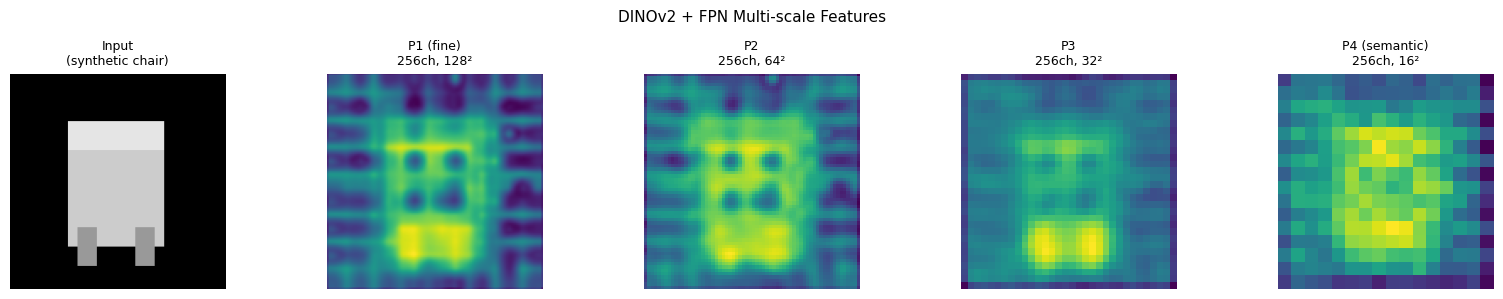

In [5]:
from matplotlib import pyplot as plt

test_img = torch.zeros(1, 3, 224, 224)
test_img[0, :, 50:180, 60:160] = 0.8
test_img[0, :, 160:200, 70:90]  = 0.6
test_img[0, :, 160:200, 130:150] = 0.6
test_img[0, :, 50:80,   60:160]  = 0.9

encoder.eval()
with torch.no_grad():
    feats_vis = encoder(test_img.to(DEVICE))

fig, axes = plt.subplots(1, 5, figsize=(16, 3))
axes[0].imshow(test_img[0].permute(1,2,0).clamp(0,1))
axes[0].set_title("Input\n(synthetic chair)", fontsize=9); axes[0].axis("off")

names = ["P1 (fine)\n256ch, 128²", "P2\n256ch, 64²", "P3\n256ch, 32²", "P4 (semantic)\n256ch, 16²"]
for ax, fm, name in zip(axes[1:], feats_vis, names):
    ax.imshow(fm[0].mean(0).cpu(), cmap="viridis")
    ax.set_title(name, fontsize=9); ax.axis("off")

plt.suptitle("DINOv2 + FPN Multi-scale Features", fontsize=11)
plt.tight_layout()
plt.show()

## GCN

Identical to notebook 5.

In [6]:
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.fc_self  = nn.Linear(in_dim, out_dim, bias=False)
        self.fc_neigh = nn.Linear(in_dim, out_dim, bias=False)
        self.bn   = nn.BatchNorm1d(out_dim)
        self.bias = nn.Parameter(torch.zeros(out_dim))

    def forward(self, x, adj):
        B, V, _ = x.shape
        neigh = torch.einsum("vw,bwf->bvf", adj, x)
        out = self.fc_self(x) + self.fc_neigh(neigh) + self.bias
        out = self.bn(out.reshape(B*V, -1)).reshape(B, V, -1)
        return F.relu(out)


class GCNBlock(nn.Module):
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.gc1  = GraphConv(in_dim, hidden_dim)
        self.gc2  = GraphConv(hidden_dim, hidden_dim)
        self.skip = nn.Linear(in_dim, hidden_dim, bias=False) if in_dim != hidden_dim else nn.Identity()

    def forward(self, x, adj):
        return self.gc2(self.gc1(x, adj), adj) + self.skip(x)


class DeformStage(nn.Module):
    def __init__(self, feat_dim, hidden_dim=128, n_blocks=2):
        super().__init__()
        self.blocks = nn.ModuleList([
            GCNBlock(feat_dim if i == 0 else hidden_dim, hidden_dim)
            for i in range(n_blocks)
        ])
        self.disp_head = nn.Sequential(
            nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 3)
        )

    def forward(self, feats, verts, adj):
        h = feats
        for blk in self.blocks:
            h = blk(h, adj)
        return verts + self.disp_head(h), h


# Sanity check
B, FC, H = 2, 64, 128
V = v1.shape[0]
adj_test = build_adjacency(v1, f1)
stage_test = DeformStage(feat_dim=FC, hidden_dim=H, n_blocks=2)
dummy_feats = torch.randn(B, V, FC)
dummy_verts = torch.randn(B, V, 3)
new_v, h_out = stage_test(dummy_feats, dummy_verts, adj_test)
print(f"GCN  in: {tuple(dummy_verts.shape)}  out: {tuple(new_v.shape)}  hidden: {tuple(h_out.shape)}")

GCN  in: (2, 26, 3)  out: (2, 26, 3)  hidden: (2, 26, 128)


## Furniture3D model

Same architecture as notebook 5. The only change is that `encoder.feat_dims = [256,256,256,256]` so `total_img = 1024` instead of 960.

In [7]:
class Furniture3D(nn.Module):
    def __init__(self, encoder, hidden_dim=256, n_stages=3, n_gcn_blocks=3):
        super().__init__()
        self.n_stages   = n_stages
        self.hidden_dim = hidden_dim
        self.encoder    = encoder
        total_img = sum(self.encoder.feat_dims)  # 1024

        self.projectors    = nn.ModuleList()
        self.deform_stages = nn.ModuleList()
        for i in range(n_stages):
            in_dim = (total_img + 3) if i == 0 else (total_img + hidden_dim + 3)
            self.projectors.append(nn.Sequential(
                nn.Linear(in_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.ReLU(),
            ))
            self.deform_stages.append(DeformStage(hidden_dim, hidden_dim, n_gcn_blocks))

        self._build_templates(n_stages)

    def _build_templates(self, n_stages):
        verts, faces = get_unit_cube()
        self.templates = []
        for i in range(n_stages):
            adj = build_adjacency(verts, faces)
            lap = build_laplacian(verts, faces)
            self.register_buffer(f"adj_{i}", adj)
            self.register_buffer(f"lap_{i}", lap)
            self.templates.append((verts.clone(), faces.clone()))
            if i < n_stages - 1:
                verts, faces = loop_subdivide(verts, faces)

    def forward(self, image, rot, trans, focal):
        B, device = image.shape[0], image.device
        feat_maps = self.encoder(image)
        all_verts, all_faces, all_laps = [], [], []
        prev_h = None

        for i in range(self.n_stages):
            adj = getattr(self, f"adj_{i}").to(device)
            lap = getattr(self, f"lap_{i}").to(device)
            verts_tmpl, faces = self.templates[i]
            verts = verts_tmpl.to(device).unsqueeze(0).expand(B, -1, -1).clone()
            V = verts.shape[1]

            coords   = project_vertices(verts, rot, trans, focal)  # [B,V,2]
            img_feat = sample_features(feat_maps, coords)           # [B,V,1024]

            if prev_h is None:
                combined = torch.cat([img_feat, verts], dim=-1)
            else:
                if prev_h.shape[1] != V:
                    prev_h = F.interpolate(
                        prev_h.permute(0, 2, 1), size=V, mode="linear", align_corners=False
                    ).permute(0, 2, 1)
                combined = torch.cat([img_feat, prev_h, verts], dim=-1)

            vertex_feats = self.projectors[i](combined)
            new_verts, hidden = self.deform_stages[i](vertex_feats, verts, adj)

            all_verts.append(new_verts)
            all_faces.append(faces)
            all_laps.append(lap)
            prev_h = hidden

        return {"vertices": all_verts, "faces": all_faces, "laplacians": all_laps}


# hidden_dim=256, n_gcn_blocks=3 — bigger than notebook 5 to match encoder capacity
model = Furniture3D(encoder=encoder, hidden_dim=256, n_stages=3, n_gcn_blocks=3).to(DEVICE)

total_p = sum(p.numel() for p in model.parameters())
train_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_p:>12,}")
print(f"Trainable       : {train_p:>12,}")
print(f"Frozen (encoder): {total_p - train_p:>12,}")

Total params    :   28,357,257
Trainable       :    6,300,681
Frozen (encoder):   22,056,576


### Forward pass sanity check

In [8]:
B = 2
img_test   = torch.randn(B, 3, 224, 224, device=DEVICE)
rot_test   = torch.eye(3, device=DEVICE).unsqueeze(0).expand(B, -1, -1).clone()
trans_test = torch.zeros(B, 3, device=DEVICE); trans_test[:, 2] = 2.0
focal_test = torch.ones(B, device=DEVICE) * 0.85

model.eval()
with torch.no_grad():
    out = model(img_test, rot_test, trans_test, focal_test)

print("Forward pass output:")
for i, v in enumerate(out["vertices"]):
    f = out["faces"][i]
    print(f"  Stage {i+1}: verts {tuple(v.shape)}  faces {tuple(f.shape)}")

Forward pass output:
  Stage 1: verts (2, 8, 3)  faces (12, 3)
  Stage 2: verts (2, 26, 3)  faces (48, 3)
  Stage 3: verts (2, 98, 3)  faces (192, 3)


## Loss functions

Identical to notebook 5.

In [9]:
def chamfer_distance(pred, gt):
    """Bidirectional Chamfer. pred,gt: [B,N,3]"""
    d = ((pred.unsqueeze(2) - gt.unsqueeze(1))**2).sum(-1)
    return d.min(2).values.mean() + d.min(1).values.mean()


def edge_loss(vertices, faces):
    v0, v1, v2 = vertices[:,faces[:,0]], vertices[:,faces[:,1]], vertices[:,faces[:,2]]
    return torch.stack([
        (v0-v1).norm(dim=-1), (v1-v2).norm(dim=-1), (v2-v0).norm(dim=-1)
    ]).mean()


def laplacian_loss(vertices, lap):
    return (torch.einsum("vw,bwc->bvc", lap, vertices)**2).mean()


def compute_loss(pred_verts, gt_pts, faces, lap, w_cd=1.0, w_edge=0.1, w_lap=0.5):
    cd  = chamfer_distance(pred_verts, gt_pts)
    el  = edge_loss(pred_verts, faces)
    lpl = laplacian_loss(pred_verts, lap)
    total = w_cd*cd + w_edge*el + w_lap*lpl
    return total, {"chamfer": cd.item(), "edge": el.item(), "laplacian": lpl.item()}


# Quick check
pred_v   = out["vertices"][2]
gt_pts   = torch.randn(2, 2048, 3, device=DEVICE) * 0.4
faces_s3 = out["faces"][2].to(DEVICE)
lap_s3   = out["laplacians"][2].to(DEVICE)

loss_val, breakdown = compute_loss(pred_v, gt_pts, faces_s3, lap_s3)
print(f"Total : {loss_val.item():.4f}")
for k, v in breakdown.items(): print(f"  {k:12s}: {v:.4f}")

Total : 0.1400
  chamfer     : 0.1101
  edge        : 0.2834
  laplacian   : 0.0032


## Dataset

Identical to notebook 5 — Pix3D with chair category.

In [10]:
import os, json, random
from PIL import Image
from torchvision import transforms

PIX3D_CATS   = ["bed","bookcase","chair","desk","misc","sofa","table","tool","wardrobe"]
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# DINOv2 was trained with a different normalisation — use its own stats for best results
DINO_MEAN = [0.485, 0.456, 0.406]
DINO_STD  = [0.229, 0.224, 0.225]


def load_obj(path):
    verts, faces = [], []
    with open(path) as fh:
        for line in fh:
            p = line.strip().split()
            if not p: continue
            if p[0] == "v":   verts.append([float(x) for x in p[1:4]])
            elif p[0] == "f":
                idx = [int(x.split("/")[0])-1 for x in p[1:]]
                for i in range(1, len(idx)-1):
                    faces.append([idx[0], idx[i], idx[i+1]])
    return torch.tensor(verts, dtype=torch.float32), torch.tensor(faces, dtype=torch.long)


def normalise_mesh(v):
    v = v - (v.max(0).values + v.min(0).values) / 2
    return v / v.norm(dim=-1).max().clamp(1e-8)


def sample_surface(verts, faces, n=2048):
    v0, v1, v2 = verts[faces[:,0]], verts[faces[:,1]], verts[faces[:,2]]
    areas = 0.5 * torch.cross(v1-v0, v2-v0, dim=-1).norm(dim=-1)
    prob  = (areas / areas.sum().clamp(1e-8)).numpy()
    fi    = torch.from_numpy(np.random.choice(len(faces), n, p=prob))
    r1    = torch.rand(n).sqrt()
    u, v, w = 1-r1, r1*(1-torch.rand(n)), r1*torch.rand(n)
    return (u[:,None]*verts[faces[fi,0]]
          + v[:,None]*verts[faces[fi,1]]
          + w[:,None]*verts[faces[fi,2]])


class Pix3DDataset(torch.utils.data.Dataset):
    def __init__(self, root, split="train", categories=None, img_size=224, n_pts=2048):
        self.root  = root
        self.n_pts = n_pts
        with open(os.path.join(root, "pix3d.json")) as f:
            anns = json.load(f)
        cats = set(categories or PIX3D_CATS)
        anns = [a for a in anns if a["category"] in cats
                and not a.get("truncated") and not a.get("occluded")]
        random.seed(42); random.shuffle(anns)
        n = len(anns)
        splits = {"train": anns[:int(0.8*n)], "val": anns[int(0.8*n):int(0.9*n)], "test": anns[int(0.9*n):]}
        self.samples = splits[split]
        self.tfm = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(DINO_MEAN, DINO_STD),
        ])

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        a     = self.samples[idx]
        image = self.tfm(Image.open(os.path.join(self.root, a["img"])).convert("RGB"))
        verts, faces = load_obj(os.path.join(self.root, a["model"]))
        verts  = normalise_mesh(verts)
        gt_pts = sample_surface(verts, faces, self.n_pts)
        rot   = torch.tensor(a["rot_mat"],   dtype=torch.float32)
        trans = torch.tensor(a["trans_mat"], dtype=torch.float32)
        w, h  = a["img_size"]
        focal = torch.tensor(a["focal_length"] / (max(w,h)/2.), dtype=torch.float32)
        return {"image": image, "gt_points": gt_pts, "rot": rot, "trans": trans, "focal": focal}


PIX3D_ROOT = "../data/pix3d"
ds = Pix3DDataset(PIX3D_ROOT, "train", categories=["chair"])
print(f"{len(ds)} training samples")
sample = ds[0]
print({k: tuple(v.shape) if hasattr(v, "shape") else v for k, v in sample.items()})

2451 training samples
{'image': (3, 224, 224), 'gt_points': (2048, 3), 'rot': (3, 3), 'trans': (3,), 'focal': ()}


## Training loop

Two changes from notebook 5:
1. **Encoder LR = 0** when frozen (no grad anyway, but keeps optimizer state clean)
2. **FPN LR = 1e-4** — FPN neck is trainable and learns to route DINOv2 features

In [11]:
import time
from tqdm.auto import tqdm
from IPython.display import display, clear_output
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

STAGE_WEIGHTS = [0.2, 0.3, 0.5]


def _render_step(fig, axes, step_losses, val_losses, epoch, n_epochs,
                 pred_verts_list, faces_list, gt_pts, device):
    for ax in axes:
        ax.cla()

    ax_loss = axes[0]
    ax_loss.plot(step_losses, color="#4A90D9", linewidth=1.2, label="train (step)")
    if val_losses:
        x_val = [int(i * len(step_losses) / len(val_losses)) for i in range(len(val_losses))]
        ax_loss.plot(x_val, val_losses, "o--", color="#E8672A", linewidth=1.2, markersize=4, label="val (epoch)")
    ax_loss.set_title(f"Loss  (epoch {epoch}/{n_epochs})", fontsize=9)
    ax_loss.set_xlabel("step", fontsize=8); ax_loss.set_ylabel("loss", fontsize=8)
    ax_loss.legend(fontsize=8); ax_loss.tick_params(labelsize=7)
    ax_loss.grid(True, linewidth=0.4, alpha=0.5)

    stage_colors = ["#4A90D9", "#7B68EE", "#E8672A"]
    if gt_pts is not None:
        gp = gt_pts[0].detach().cpu().numpy()
        axes[1].scatter(*gp.T, s=1, c="#20B2AA", alpha=0.4)
        axes[1].set_title("GT Point Cloud", fontsize=9); axes[1].set_axis_off()

    for i, (verts, faces) in enumerate(zip(pred_verts_list, faces_list)):
        ax  = axes[2 + i]
        pv  = verts[0].detach().cpu().numpy()
        ff  = faces.cpu().numpy()
        tris = [pv[f] for f in ff]
        poly = Poly3DCollection(tris, alpha=0.3, facecolor=stage_colors[i], edgecolor="#555", linewidth=0.1)
        ax.add_collection3d(poly)
        lim = 0.6
        ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_zlim(-lim, lim)
        ax.set_title(f"Stage {i+1}  {pv.shape[0]}V", fontsize=9); ax.set_axis_off()

    fig.suptitle(f"Training progress — epoch {epoch}/{n_epochs}", fontsize=11)
    fig.tight_layout()
    clear_output(wait=True); display(fig)


def train(model, loader, optimizer, scheduler=None, n_epochs=100, val_loader=None, vis_every=20, device=DEVICE):
    history = {"train": [], "val": []}
    step_losses, val_losses = [], []

    n_stages = model.n_stages
    n_cols   = 1 + 1 + n_stages
    fig      = plt.figure(figsize=(4 * n_cols, 4))
    axes_flat = [fig.add_subplot(1, n_cols, 1)]
    axes_flat.append(fig.add_subplot(1, n_cols, 2, projection="3d"))
    for k in range(n_stages):
        axes_flat.append(fig.add_subplot(1, n_cols, 3 + k, projection="3d"))
    plt.close(fig)

    last_out, last_gt = None, None
    global_step = 0

    epoch_bar = tqdm(range(1, n_epochs + 1), desc="Epochs", unit="epoch")
    for epoch in epoch_bar:
        model.train()
        epoch_loss, t0 = 0.0, time.time()

        step_bar = tqdm(loader, desc=f"Train {epoch}/{n_epochs}", leave=False, unit="batch")
        for batch in step_bar:
            img   = batch["image"].to(device)
            gt    = batch["gt_points"].to(device)
            rot   = batch["rot"].to(device)
            trans = batch["trans"].to(device)
            focal = batch["focal"].to(device)

            optimizer.zero_grad()
            out  = model(img, rot, trans, focal)
            loss = torch.tensor(0., device=device)
            for verts, faces, lap, w in zip(out["vertices"], out["faces"], out["laplacians"], STAGE_WEIGHTS):
                l, _ = compute_loss(verts, gt, faces.to(device), lap.to(device))
                loss = loss + w * l

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            epoch_loss += loss.item()
            step_losses.append(loss.item())
            last_out, last_gt = out, gt
            global_step += 1
            step_bar.set_postfix(loss=f"{loss.item():.4f}")

            if global_step % vis_every == 0:
                _render_step(fig, axes_flat, step_losses, val_losses, epoch, n_epochs,
                             last_out["vertices"], last_out["faces"], last_gt, device)

        train_avg = epoch_loss / len(loader)
        history["train"].append(train_avg)

        val_avg = None
        if val_loader:
            model.eval()
            v_loss = 0.0
            with torch.no_grad():
                val_bar = tqdm(val_loader, desc=f"Val   {epoch}/{n_epochs}", leave=False, unit="batch")
                for batch in val_bar:
                    img   = batch["image"].to(device)
                    gt    = batch["gt_points"].to(device)
                    rot   = batch["rot"].to(device)
                    trans = batch["trans"].to(device)
                    focal = batch["focal"].to(device)
                    out   = model(img, rot, trans, focal)
                    for verts, faces, lap, w in zip(out["vertices"], out["faces"], out["laplacians"], STAGE_WEIGHTS):
                        l, _ = compute_loss(verts, gt, faces.to(device), lap.to(device))
                        v_loss += w * l.item()
                    val_bar.set_postfix(loss=f"{v_loss / (val_bar.n or 1):.4f}")
            val_avg = v_loss / len(val_loader)
            history["val"].append(val_avg)
            val_losses.append(val_avg)

        if scheduler is not None:
            scheduler.step()

        if last_out is not None:
            _render_step(fig, axes_flat, step_losses, val_losses, epoch, n_epochs,
                         last_out["vertices"], last_out["faces"], last_gt, device)

        postfix = {"train": f"{train_avg:.4f}", "time": f"{time.time()-t0:.1f}s"}
        if val_avg is not None: postfix["val"] = f"{val_avg:.4f}"
        epoch_bar.set_postfix(**postfix)

    plt.close(fig)
    return history


print("Training loop defined.")

Training loop defined.


/Users/michaeleko/miniconda3/envs/floor-plan/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Smoke test

In [12]:
smoke_model = Furniture3D(encoder=encoder, hidden_dim=128, n_stages=3, n_gcn_blocks=2).to(DEVICE)

# Parameter groups:
#   dino (frozen)  →  lr effectively 0
#   fpn lateral + output convs  →  lr 1e-4  (learns to route ViT features)
#   GCN + projectors  →  lr 3e-4
fpn_params = list(smoke_model.encoder.lateral.parameters()) + list(smoke_model.encoder.output_convs.parameters())
gcn_params = [p for n, p in smoke_model.named_parameters() if "encoder" not in n]

smoke_opt = torch.optim.AdamW([
    {"params": fpn_params, "lr": 1e-4},
    {"params": gcn_params, "lr": 3e-4},
], weight_decay=1e-4)

smoke_model.train()
for step in range(3):
    bs      = 2
    img_s   = torch.randn(bs, 3, 224, 224, device=DEVICE)
    gt_s    = torch.randn(bs, 2048, 3, device=DEVICE)
    rot_s   = torch.eye(3, device=DEVICE).unsqueeze(0).expand(bs,-1,-1).clone()
    trans_s = torch.zeros(bs, 3, device=DEVICE); trans_s[:,2] = 2.0
    focal_s = torch.ones(bs, device=DEVICE) * 0.85

    smoke_opt.zero_grad()
    out  = smoke_model(img_s, rot_s, trans_s, focal_s)
    loss = torch.tensor(0., device=DEVICE)
    for verts, faces, lap, w in zip(out["vertices"], out["faces"], out["laplacians"], STAGE_WEIGHTS):
        l, _ = compute_loss(verts, gt_s, faces.to(DEVICE), lap.to(DEVICE))
        loss = loss + w * l
    loss.backward()
    smoke_opt.step()
    print(f"  Step {step+1} | loss={loss.item():.4f}")

print("Smoke test PASSED ✓")

  Step 1 | loss=1.4508
  Step 2 | loss=1.3796
  Step 3 | loss=1.2446
Smoke test PASSED ✓


## Run training

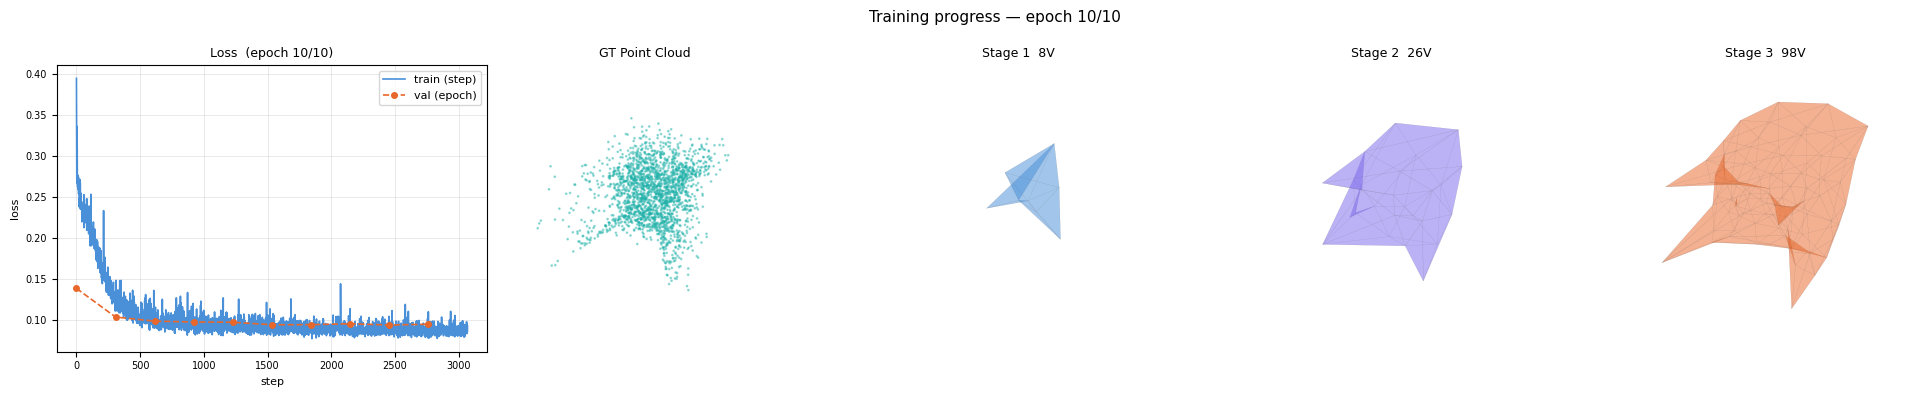

Epochs: 100%|██████████| 10/10 [1:36:14<00:00, 577.46s/epoch, time=557.0s, train=0.0869, val=0.0944]


In [13]:
from torch.utils.data import DataLoader

batch_size = 8
num_workers = 0

train_ds = Pix3DDataset(PIX3D_ROOT, "train", categories=["chair"])
val_ds = Pix3DDataset(PIX3D_ROOT, "val", categories=["chair"])
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

model = Furniture3D(encoder=encoder, hidden_dim=256, n_stages=3, n_gcn_blocks=3).to(DEVICE)

fpn_params = list(model.encoder.lateral.parameters()) + list(model.encoder.output_convs.parameters())
gcn_params = [p for n, p in model.named_parameters() if "encoder" not in n]

optimizer = torch.optim.AdamW([
    {"params": fpn_params, "lr": 1e-4},
    {"params": gcn_params, "lr": 3e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
history = train(model, train_loader, optimizer, scheduler=scheduler, n_epochs=10, vis_every=5, val_loader=val_loader)

## Visualise results

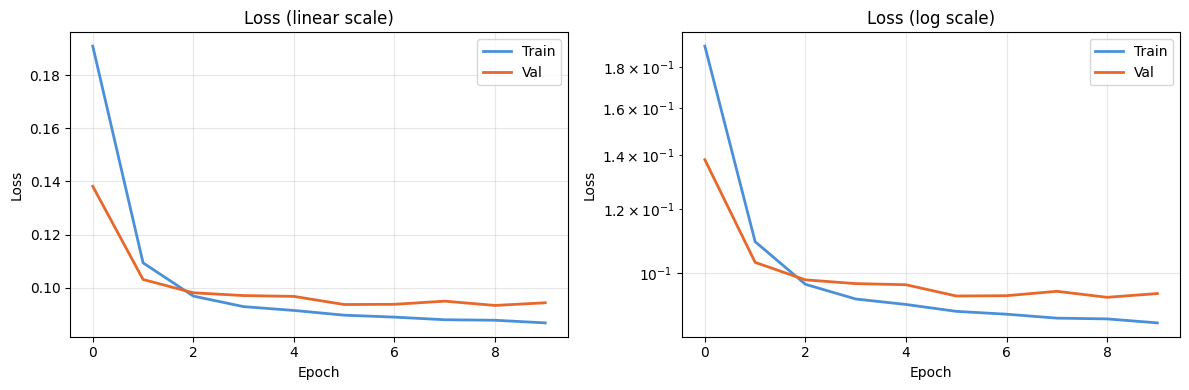

In [14]:
def plot_history(history):
    has_val = bool(history.get("val"))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, yscale in zip(axes, ["linear", "log"]):
        ax.plot(history["train"], label="Train", c="#4A90D9", lw=2)
        if has_val: ax.plot(history["val"], label="Val", c="#E8672A", lw=2)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.set_yscale(yscale); ax.set_title(f"Loss ({yscale} scale)")
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def visualise(pred_verts_list, gt_pts, faces_list, title=""):
    n = len(pred_verts_list)
    fig = plt.figure(figsize=(5*n + 4, 4))
    colors = ["#4A90D9","#7B68EE","#E8672A"]

    ax = fig.add_subplot(1, n+1, 1, projection="3d")
    gp = gt_pts[0].cpu().numpy()
    ax.scatter(*gp.T, s=1, c="#20B2AA", alpha=0.4)
    ax.set_title("GT Point Cloud", fontsize=9); ax.set_axis_off()

    for i, (verts, faces) in enumerate(zip(pred_verts_list, faces_list)):
        ax  = fig.add_subplot(1, n+1, i+2, projection="3d")
        pv  = verts[0].detach().cpu().numpy()
        ff  = faces.cpu().numpy()
        tris = [pv[f] for f in ff]
        poly = Poly3DCollection(tris, alpha=0.3, facecolor=colors[i], edgecolor="#555", linewidth=0.1)
        ax.add_collection3d(poly)
        lim = 0.6
        ax.set_xlim(-lim,lim); ax.set_ylim(-lim,lim); ax.set_zlim(-lim,lim)
        cd = chamfer_distance(verts[:1].to(DEVICE), gt_pts[:1].to(DEVICE))
        ax.set_title(f"Stage {i+1}\n{pv.shape[0]}V | CD={cd.item():.4f}", fontsize=9)
        ax.set_axis_off()

    if title: plt.suptitle(title, y=1.02, fontsize=11)
    plt.tight_layout(); plt.show()


plot_history(history)

### Evaluate on a validation batch

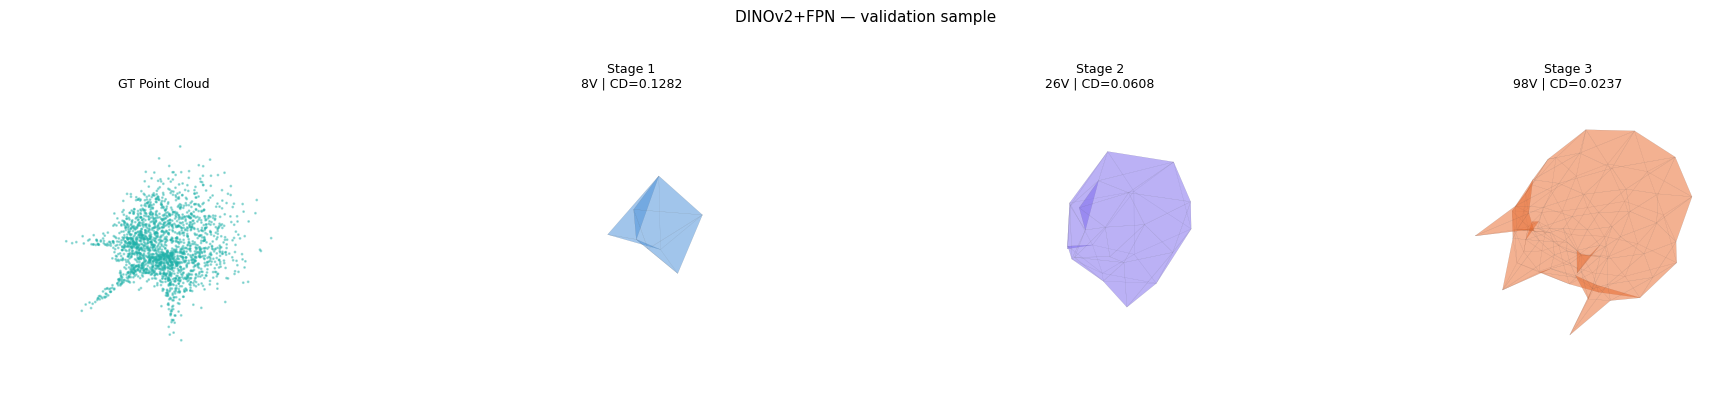

In [15]:
model.eval()
batch = next(iter(val_loader))
with torch.no_grad():
    out = model(
        batch["image"].to(DEVICE),
        batch["rot"].to(DEVICE),
        batch["trans"].to(DEVICE),
        batch["focal"].to(DEVICE),
    )

visualise(out["vertices"], batch["gt_points"].to(DEVICE), out["faces"], title="DINOv2+FPN — validation sample")

## Checkpoint

In [16]:
def save_ckpt(model, optimizer, epoch, path, val_cd=None):
    torch.save({
        "epoch": epoch,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "val_cd": val_cd,
    }, path)
    print(f"Saved → {path}")


def load_ckpt(model, path, optimizer=None, device=None):
    ckpt = torch.load(path, map_location=device or "cpu")
    model.load_state_dict(ckpt["model"])
    if optimizer: optimizer.load_state_dict(ckpt["optimizer"])
    print(f"Loaded epoch={ckpt['epoch']} val_cd={ckpt.get('val_cd')}")
    return ckpt


save_ckpt(model, optimizer, epoch=10, path="./furniture3d_dinov2.pth")

Saved → ./furniture3d_dinov2.pth


## Save Quantized Model

Using **Post-Training Dynamic Quantization (PTQ)** — the simplest and most compatible option.

| Method | What it does | Tradeoff |
|---|---|---|
| **Dynamic (used here)** | Quantizes `Linear` weights to int8 at save time; activations quantized on-the-fly | No calibration data needed, works anywhere |
| Static | Quantizes both weights + activations | Needs a calibration dataset, faster inference |
| QAT | Re-trains with fake quantization | Best accuracy, most expensive |

Dynamic is the right default for a GCN: the irregular graph ops and variable vertex counts make static quantization fragile. The DINOv2 backbone is kept in float32 since it's frozen and already optimal.

In [19]:
import torch.quantization

def save_quantized(model, path):
    model.eval().cpu()

    # Only quantize the trainable Linear layers in the GCN + projectors.
    # The DINOv2 ViT and FPN Conv2d layers are excluded:
    #   - ViT attention uses custom ops incompatible with dynamic quant
    #   - Conv2d is not supported by dynamic quantization (only Linear + LSTM)
    quantized = torch.quantization.quantize_dynamic(
        model,
        qconfig_spec={nn.Linear},
        dtype=torch.qint8,
    )

    torch.save({
        "model_state": quantized.state_dict(),
        "quantized": True,
        "hidden_dim": model.hidden_dim,
        "n_stages": model.n_stages,
    }, path)

    orig_mb  = sum(p.numel() * p.element_size() for p in model.parameters()) / 1e6
    quant_mb = sum(
        p.numel() * p.element_size() for p in quantized.parameters()
    ) / 1e6
    print(f"Original  : {orig_mb:.1f} MB")
    print(f"Quantized : {quant_mb:.1f} MB  ({100*(1 - quant_mb/orig_mb):.0f}% smaller)")
    print(f"Saved → {path}")
    return quantized


def load_quantized(path, encoder, device="cpu"):
    ckpt = torch.load(path, map_location=device)
    assert ckpt.get("quantized"), "Checkpoint was not saved as quantized"

    # Rebuild model architecture, then apply dynamic quant to match saved state
    m = Furniture3D(
        encoder=encoder,
        hidden_dim=ckpt["hidden_dim"],
        n_stages=ckpt["n_stages"],
    ).to(device)
    m.eval()
    m = torch.quantization.quantize_dynamic(m, qconfig_spec={nn.Linear}, dtype=torch.qint8)
    m.load_state_dict(ckpt["model_state"])
    print(f"Loaded quantized model — hidden_dim={ckpt['hidden_dim']} n_stages={ckpt['n_stages']}")
    return m


# Quantize and save
quantized_model = save_quantized(model, "./furniture3d_dinov2_int8.pth")

Original  : 113.4 MB
Quantized : 14.2 MB  (87% smaller)
Saved → ./furniture3d_dinov2_int8.pth


/var/folders/jk/6rmpyfhs617dj90p08kjywc80000gn/T/ipykernel_57824/3279388740.py:10: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized = torch.quantization.quantize_dynamic(


In [20]:
# Verify the quantized model produces the same output shape and similar Chamfer Distance
quantized_model.eval()
batch = next(iter(val_loader))

with torch.no_grad():
    out_fp32 = model.cpu().eval()(
        batch["image"], batch["rot"], batch["trans"], batch["focal"]
    )
    out_int8 = quantized_model(
        batch["image"], batch["rot"], batch["trans"], batch["focal"]
    )

gt = batch["gt_points"]
cd_fp32 = chamfer_distance(out_fp32["vertices"][2], gt).item()
cd_int8  = chamfer_distance(out_int8["vertices"][2],  gt).item()

print(f"Chamfer Distance — float32 : {cd_fp32:.4f}")
print(f"Chamfer Distance — int8    : {cd_int8:.4f}")
print(f"CD degradation             : {abs(cd_int8 - cd_fp32):.4f}  ({100*abs(cd_int8-cd_fp32)/cd_fp32:.1f}%)")

[W513 11:01:55.031355000 qlinear_dynamic.cpp:251] Warning: Currently, qnnpack incorrectly ignores reduce_range when it is set to true; this may change in a future release. (function operator())


KeyError: 2